Training Batch GD...
Training SGD...
Training Mini-Batch GD...

  Batch GD      final MSE = 0.02883
  SGD           final MSE = 0.01743
  Mini-batch GD final MSE = 0.01288


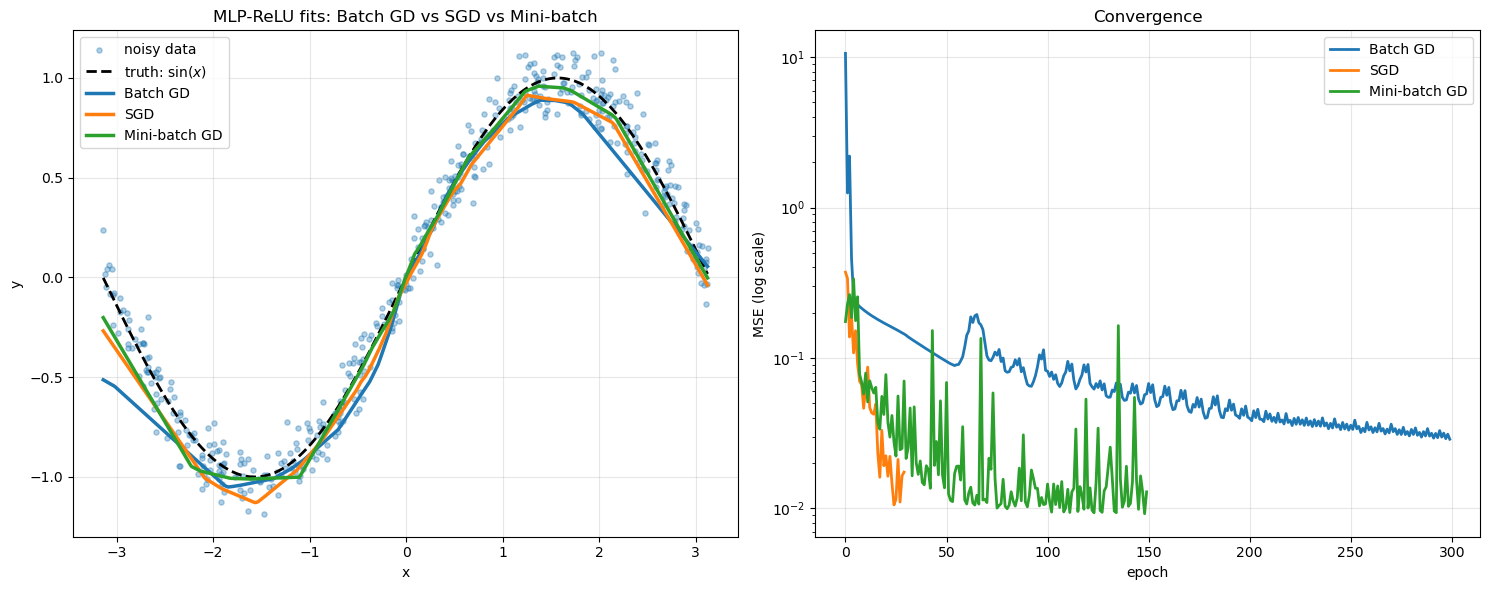

In [3]:
# =============================================================================
# MLP WITH ReLU — BATCH GD vs. SGD vs. MINI-BATCH GD
# =============================================================================
#
# ARCHITECTURE
# ------------
#   Input  x in R
#   Hidden h^(l) = ReLU( W_l h^(l-1) + b_l ),  l = 1..L,   ReLU(z) = max(0, z)
#   Output y_hat = W_(L+1) h^(L) + b_(L+1)
#
# LOSS
# ----
#   J(Theta) = (1/N) * sum_i ( y_hat_i - y_i )^2
#
# BACKPROP (chain rule)
# ---------------------
#   dL/dy_hat    = (2/m) * ( y_hat - y )
#   dL/dW_out    = dL/dy_hat  @ h^(L)^T
#   dL/db_out    = sum_i dL/dy_hat
#   dL/dh^(l)    = W_(l+1)^T @ dL/dz^(l+1)
#   dL/dz^(l)    = dL/dh^(l) * 1[ z^(l) > 0 ]     (ReLU derivative)
#   dL/dW_l      = dL/dz^(l) @ h^(l-1)^T
#   dL/db_l      = sum_i dL/dz^(l)
#
# OPTIMIZERS
# ----------
#   Batch GD    : one update per epoch using all N samples
#   SGD         : one update per sample (N updates per epoch)
#   Mini-batch  : one update per batch of size B
#   All use the same update rule:
#       Theta <- Theta - alpha * grad_Theta J
#   Gradient clipping is applied for numerical stability.
#
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# =============================================================================
# 1. DATA — NOISY SINE WAVE
# =============================================================================
def generate_data(N=300, sigma=0.25, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-np.pi, np.pi, size=N)
    y = np.sin(X) + rng.normal(0, sigma, size=N)
    return X, y


def standardize(x):
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd, mu, sd


def clip_grad(g, max_norm):
    n = np.linalg.norm(g)
    if n > max_norm:
        g = g * (max_norm / (n + 1e-12))
    return g


# =============================================================================
# 2. MLP WITH ReLU
# =============================================================================
class MLP:
    """Fully-connected MLP with ReLU hidden layers and a linear output."""

    def __init__(self, layer_sizes, seed=0):
        rng = np.random.default_rng(seed)
        self.W, self.b = [], []
        for i in range(len(layer_sizes) - 1):
            fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
            scale = np.sqrt(2.0 / fan_in)          # He init for ReLU
            self.W.append(rng.normal(0, scale, size=(fan_out, fan_in)))
            self.b.append(np.zeros(fan_out))

    def forward(self, X):
        cache = {"A": [X], "Z": []}
        A = X
        for i in range(len(self.W) - 1):
            Z = A @ self.W[i].T + self.b[i]
            A = np.maximum(0.0, Z)                 # ReLU
            cache["Z"].append(Z)
            cache["A"].append(A)
        Z_out = A @ self.W[-1].T + self.b[-1]
        cache["Z"].append(Z_out)
        cache["A"].append(Z_out)
        return Z_out, cache

    def backward(self, cache, y):
        m = y.shape[0]
        A, Z = cache["A"], cache["Z"]
        n_layers = len(self.W)

        dZ = (2.0 / m) * (A[-1] - y.reshape(-1, 1))

        dW = [None] * n_layers
        db = [None] * n_layers

        for i in reversed(range(n_layers)):
            dW[i] = dZ.T @ A[i]
            db[i] = dZ.sum(axis=0)
            if i > 0:
                dA = dZ @ self.W[i]
                dZ = dA * (Z[i - 1] > 0)           # ReLU derivative
        return dW, db

    def apply_update(self, dW, db, lr, max_norm=5.0):
        for i in range(len(self.W)):
            gW = clip_grad(dW[i], max_norm)
            gb = clip_grad(db[i], max_norm)
            self.W[i] -= lr * gW
            self.b[i] -= lr * gb


# =============================================================================
# 3. THREE TRAINING ROUTINES — SAME MODEL, DIFFERENT OPTIMIZER
# =============================================================================
def train_batch_gd(X, y, hidden=(32, 32), lr=0.1, epochs=300, seed=0):
    """Batch GD: one update per epoch using all N samples."""
    X_col = X.reshape(-1, 1)
    y_col = y.reshape(-1, 1)

    net = MLP([1, *hidden, 1], seed=seed)
    losses = []

    for _ in range(epochs):
        _, cache = net.forward(X_col)
        dW, db = net.backward(cache, y_col)
        net.apply_update(dW, db, lr)
        y_hat, _ = net.forward(X_col)
        losses.append(float(np.mean((y_hat - y_col) ** 2)))
    return net, losses


def train_sgd(X, y, hidden=(32, 32), lr=0.005, epochs=30, seed=0):
    """SGD: one update per sample."""
    X_col = X.reshape(-1, 1)
    y_col = y.reshape(-1, 1)

    net = MLP([1, *hidden, 1], seed=seed)
    losses = []
    N = X_col.shape[0]
    rng = np.random.default_rng(seed + 1)

    for _ in range(epochs):
        for i in rng.permutation(N):
            Xi = X_col[i:i + 1]
            yi = y_col[i:i + 1]
            _, cache = net.forward(Xi)
            dW, db = net.backward(cache, yi)
            net.apply_update(dW, db, lr)
        y_hat, _ = net.forward(X_col)
        losses.append(float(np.mean((y_hat - y_col) ** 2)))
    return net, losses


def train_minibatch_gd(X, y, hidden=(32, 32), lr=0.02,
                       epochs=150, batch_size=16, seed=0):
    """Mini-batch GD: one update per batch of size B."""
    X_col = X.reshape(-1, 1)
    y_col = y.reshape(-1, 1)

    net = MLP([1, *hidden, 1], seed=seed)
    losses = []
    N = X_col.shape[0]
    rng = np.random.default_rng(seed + 1)

    for _ in range(epochs):
        idx = rng.permutation(N)
        for s in range(0, N, batch_size):
            b = idx[s:s + batch_size]
            Xb, yb = X_col[b], y_col[b]
            _, cache = net.forward(Xb)
            dW, db = net.backward(cache, yb)
            net.apply_update(dW, db, lr)
        y_hat, _ = net.forward(X_col)
        losses.append(float(np.mean((y_hat - y_col) ** 2)))
    return net, losses


# =============================================================================
# 4. RUN ALL THREE
# =============================================================================
X, y = generate_data(N=500, sigma=0.1, seed=0)
X_std, mu, sd = standardize(X)

print("Training Batch GD...")
net_bgd, losses_bgd = train_batch_gd(
    X_std, y, hidden=(32, 32), lr=0.1, epochs=300, seed=0
)

print("Training SGD...")
net_sgd, losses_sgd = train_sgd(
    X_std, y, hidden=(32, 32), lr=0.005, epochs=30, seed=0
)

print("Training Mini-Batch GD...")
net_mbgd, losses_mbgd = train_minibatch_gd(
    X_std, y, hidden=(32, 32), lr=0.02, epochs=150,
    batch_size=16, seed=0
)

print()
print(f"  Batch GD      final MSE = {losses_bgd[-1]:.5f}")
print(f"  SGD           final MSE = {losses_sgd[-1]:.5f}")
print(f"  Mini-batch GD final MSE = {losses_mbgd[-1]:.5f}")


# =============================================================================
# 5. EVALUATE ON A DENSE GRID AND PLOT
# =============================================================================
x_grid = np.linspace(X.min(), X.max(), 500)
x_grid_std = (x_grid - mu) / sd
Xs_true = np.sin(x_grid)

def mlp_predict(net, xg):
    y_hat, _ = net.forward(xg.reshape(-1, 1))
    return y_hat.ravel()

y_bgd  = mlp_predict(net_bgd,  x_grid_std)
y_sgd  = mlp_predict(net_sgd,  x_grid_std)
y_mbgd = mlp_predict(net_mbgd, x_grid_std)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left: fits ----
ax = axes[0]
ax.scatter(X, y, s=14, alpha=0.35, label="noisy data")
ax.plot(x_grid, Xs_true, "k--", lw=2, label=r"truth: $\sin(x)$")
ax.plot(x_grid, y_bgd,  lw=2.5, label="Batch GD")
ax.plot(x_grid, y_sgd,  lw=2.5, label="SGD")
ax.plot(x_grid, y_mbgd, lw=2.5, label="Mini-batch GD")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("MLP-ReLU fits: Batch GD vs SGD vs Mini-batch")
ax.legend()

# ---- Right: convergence ----
ax = axes[1]
ax.plot(losses_bgd,  lw=2, label="Batch GD")
ax.plot(losses_sgd,  lw=2, label="SGD")
ax.plot(losses_mbgd, lw=2, label="Mini-batch GD")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Convergence")
ax.legend()

plt.tight_layout()
plt.savefig("mlp_optimizers.png", dpi=130)
plt.show()